Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

CREATING INTEGRATED FOOD DETECTOR
LOADING 3-MODEL SMART ENSEMBLE

All 3 models loaded successfully!
   V21: 75.5% mAP50
   V24: 70.9% mAP50
   V25: 70.5% mAP50

Strategy:
   - SPECIFIC FOODS: Only from V25 (no voting)
   - OTHER FOODS: Need 2/3 models to agree (voting)
Loading pretrained image classifier...
Pretrained classifier ready!

Integrated Food Detector ready!

UPLOAD TEST IMAGES
Please upload food images to test (select multiple files):


Saving 29fdb34025c59fa17af804acac85e0ec.jpg to 29fdb34025c59fa17af804acac85e0ec.jpg
Saving D.jpg to D.jpg
Saving d61.PNG to d61.PNG
Saving nalinda_puttalam.jpg to nalinda_puttalam (1).jpg

Uploaded 4 images

RUNNING TESTS

######################################################################
PROCESSING IMAGE 1: 29fdb34025c59fa17af804acac85e0ec.jpg
######################################################################

[STEP 1] FOOD / NON-FOOD CLASSIFIER
   [Classifier] plate: 0.315
[Classifier] Found food-related class: plate

[STEP 2] ENSEMBLE DETECTION

ANALYZING: 29fdb34025c59fa17af804acac85e0ec.jpg

image 1/1 /content/test_images/29fdb34025c59fa17af804acac85e0ec.jpg: 640x544 1 Dhal Curry, 2 Papadams, 1 Pol Sambol, 71.3ms
Speed: 5.0ms preprocess, 71.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 544)
   V21: ['Papadam', 'Pol Sambol', 'Dhal Curry', 'Papadam']

image 1/1 /content/test_images/29fdb34025c59fa17af804acac85e0ec.jpg: 640x544 1 Chicken curry, 1 Dhal Curry,

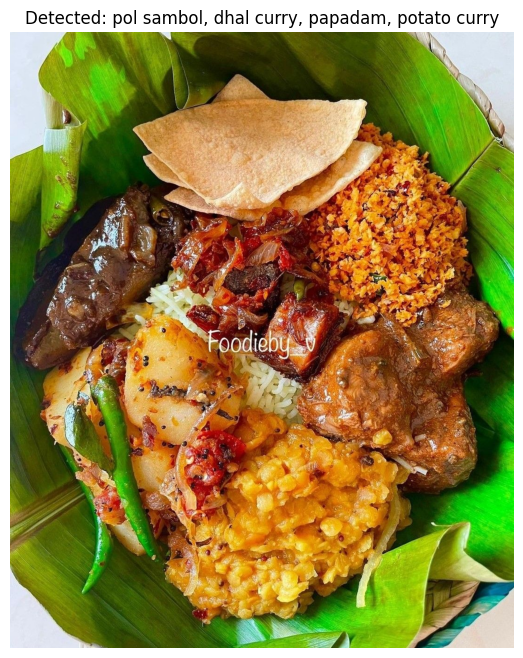


END OF IMAGE 1
######################################################################

######################################################################
PROCESSING IMAGE 2: D.jpg
######################################################################

[STEP 1] FOOD / NON-FOOD CLASSIFIER
   [Classifier] plate: 0.223
[Classifier] Found food-related class: plate

[STEP 2] ENSEMBLE DETECTION

ANALYZING: D.jpg

image 1/1 /content/test_images/D.jpg: 640x448 1 Sweets, 80.6ms
Speed: 5.1ms preprocess, 80.6ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 448)
   V21: ['Sweets']

image 1/1 /content/test_images/D.jpg: 640x448 1 Sweets, 15.2ms
Speed: 3.5ms preprocess, 15.2ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 448)
   V24: ['Sweets']

image 1/1 /content/test_images/D.jpg: 640x448 4 donuts, 22.4ms
Speed: 5.4ms preprocess, 22.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 448)
   V25: ['donut', 'donut', 'donut', 'donut']

OBSOLETE CATEGORIES

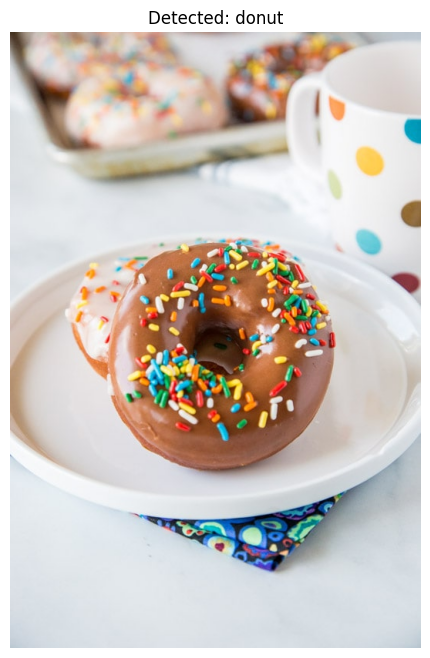


END OF IMAGE 2
######################################################################

######################################################################
PROCESSING IMAGE 3: d61.PNG
######################################################################

[STEP 1] FOOD / NON-FOOD CLASSIFIER
   [Classifier] pencil sharpener: 0.763
   [Classifier] chocolate syrup: 0.086
[Classifier] Found food-related class: chocolate syrup

[STEP 2] ENSEMBLE DETECTION

ANALYZING: d61.PNG

image 1/1 /content/test_images/d61.PNG: 480x640 1 Watalappam, 82.4ms
Speed: 4.8ms preprocess, 82.4ms inference, 1.9ms postprocess per image at shape (1, 3, 480, 640)
   V21: ['Watalappam']

image 1/1 /content/test_images/d61.PNG: 480x640 1 Watalappam, 13.9ms
Speed: 2.8ms preprocess, 13.9ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
   V24: ['Watalappam']

image 1/1 /content/test_images/d61.PNG: 480x640 1 Watalappam, 15.1ms
Speed: 2.8ms preprocess, 15.1ms inference, 1.7ms postprocess per image a

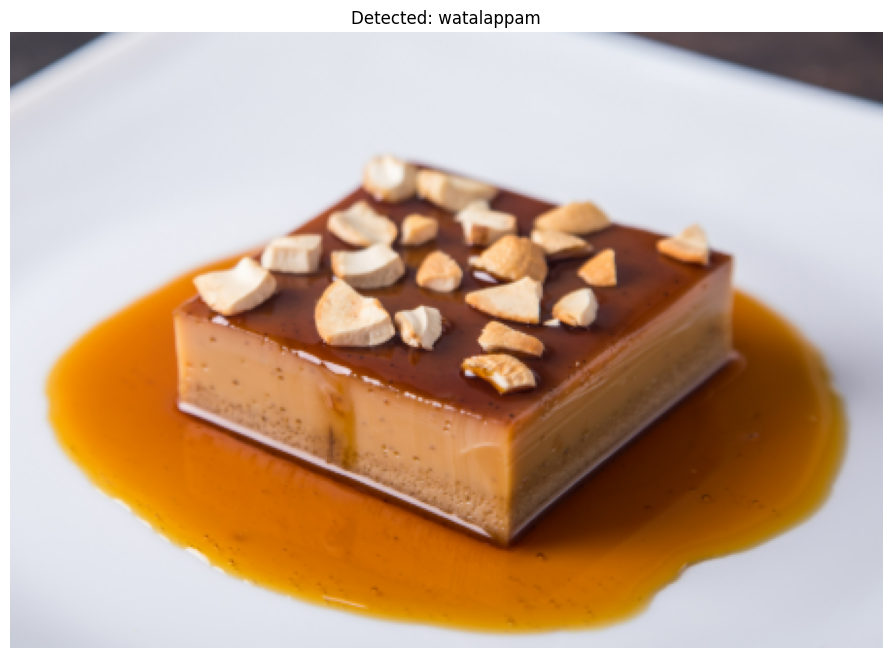


END OF IMAGE 3
######################################################################

######################################################################
PROCESSING IMAGE 4: nalinda_puttalam_(1).jpg
######################################################################

[STEP 1] FOOD / NON-FOOD CLASSIFIER
   [Classifier] patio: 0.673
   [Classifier] picket fence: 0.047
   [Classifier] mobile home: 0.034
   [Classifier] horse-drawn vehicle: 0.022
   [Classifier] boathouse: 0.011
   [Classifier] basset hound: 0.009
   [Classifier] rocking chair: 0.007
   [Classifier] sliding door: 0.007
   [Classifier] lakeshore: 0.007
   [Classifier] window screen: 0.007

RESULT: Image 'nalinda_puttalam_(1).jpg' is NOT food. Skipping detection.

TEST SUMMARY

| # | Image | V21 | V24 | V25 | FINAL |
|---|-------|-----|-----|-----|-------|
| 1 | 29fdb34025c59fa17af804aca | ['Papadam', 'Pol Sambol', 'Dhal Curry',  | ['Mango curry', 'Pol Sambol', 'Chicken c | ['Papadam', 'Pol Sambol', 'Potato Curry' | 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SMART ENSEMBLE TEST COMPLETE!


In [4]:
# ============================================================
# 3-MODEL SMART ENSEMBLE WITH VOTING SYSTEM + FOOD CHECK
# ============================================================

# Install ultralytics if not already installed
!pip install ultralytics --quiet
!pip install torchvision --quiet

from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
import os
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import json
import datetime
from collections import Counter
import torch
from torchvision import transforms, models
from PIL import Image

# ============================================================
# MODEL PATHS
# ============================================================

model_paths = {
    'V21': "/content/drive/MyDrive/TeamProject/models/srilankan_food_model_v21_74.5.pt",
    'V24': "/content/drive/MyDrive/TeamProject/models/srilankan_food_model_v24_71.9.pt",
    'V25': "/content/drive/MyDrive/TeamProject/models/srilankan_food_model_v25_70.5.pt"
}

# ============================================================
# PRETRAINED FOOD/NON-FOOD CLASSIFIER
# ============================================================

class FoodPlateClassifier:
    """Checks if an image contains food using pretrained ResNet18 (ImageNet weights)"""
    def __init__(self):
        print("Loading pretrained image classifier...")
        self.model = models.resnet18(pretrained=True)
        self.model.eval()

        # Common food-related words
        self.food_classes = [
            'pizza', 'cheeseburger', 'hotdog', 'burrito', 'taco', 'sandwich',
            'bagel', 'croissant', 'doughnut', 'pretzel', 'pancake', 'waffle',
            'omelet', 'custard', 'ice cream', 'cake', 'cupcake', 'cookie',
            'chocolate', 'pie', 'bread', 'loaf', 'banana', 'apple', 'orange',
            'strawberry', 'grape', 'pineapple', 'mushroom', 'broccoli', 'carrot',
            'cucumber', 'lettuce', 'tomato', 'potato', 'rice', 'pasta', 'soup',
            'salad', 'curry', 'dish', 'meal', 'plate', 'dinner', 'lunch',
            'breakfast', 'food', 'snack', 'dessert', 'fruit', 'vegetable'
        ]

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        print("Pretrained classifier ready!")

    def is_food_image(self, image_path, verbose=False):
        try:
            img = Image.open(image_path).convert('RGB')
            img_tensor = self.transform(img).unsqueeze(0)
            with torch.no_grad():
                outputs = self.model(img_tensor)
                probs = torch.softmax(outputs, dim=1)

            top_probs, top_indices = torch.topk(probs, 10)

            import urllib.request, json
            url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
            try:
                imagenet_labels = json.load(urllib.request.urlopen(url))
            except:
                imagenet_labels = [f"class_{i}" for i in range(1000)]

            for i in range(10):
                class_idx = top_indices[0][i].item()
                class_name = imagenet_labels[class_idx].lower()
                confidence = top_probs[0][i].item()
                if verbose:
                    print(f"   [Classifier] {class_name}: {confidence:.3f}")
                for food_word in self.food_classes:
                    if food_word in class_name:
                        if verbose:
                            print(f"[Classifier] Found food-related class: {class_name}")
                        return True
            return False
        except Exception as e:
            print(f"Error in food detection: {e}")
            return False

# ============================================================
# 3-MODEL SMART ENSEMBLE WITH VOTING
# ============================================================

class ThreeModelEnsemble:
    def __init__(self, v21_path, v24_path, v25_path):
        print("="*60)
        print("LOADING 3-MODEL SMART ENSEMBLE")
        print("="*60)

        self.v21 = YOLO(v21_path)
        self.v24 = YOLO(v24_path)
        self.v25 = YOLO(v25_path)

        self.specific_foods = [
            'donut', 'eclair', 'cake', 'brownie', 'pastry',
            'cutlets', 'roll',
            'cream bun', 'crocodile bun', 'fish bun',
            'sausage hotdog',
            'kiribath', 'kottu', 'hoppers', 'string hoppers', 'wade',
            'pittu', 'coconut roti', 'watalappam', 'lunu sambol', 'pol sambol',
            'papadam', 'gotukola mallum', 'moringa curry'
        ]

        self.obsolete_categories = [
            'fried filled', 'baked filled', 'baked sweet bun', 'sweets'
        ]

        print("\nAll 3 models loaded successfully!")
        print(f"   V21: 75.5% mAP50")
        print(f"   V24: 70.9% mAP50")
        print(f"   V25: 70.5% mAP50")
        print(f"\nStrategy:")
        print(f"   - SPECIFIC FOODS: Only from V25 (no voting)")
        print(f"   - OTHER FOODS: Need 2/3 models to agree (voting)")


    def detect(self, image_path, confidence=0.25, verbose=True):
        v21_results = self.v21(image_path, conf=confidence)[0]
        v24_results = self.v24(image_path, conf=confidence)[0]
        v25_results = self.v25(image_path, conf=confidence)[0]

        v21_foods = [v21_results.names[int(box.cls[0])].lower() for box in v21_results.boxes]
        v24_foods = [v24_results.names[int(box.cls[0])].lower() for box in v24_results.boxes]
        v25_foods = [v25_results.names[int(box.cls[0])].lower() for box in v25_results.boxes]

        v21_foods_unique = list(set(v21_foods))
        v24_foods_unique = list(set(v24_foods))
        v25_foods_unique = list(set(v25_foods))

        final_foods = []

        specific_detected = []
        for food in v25_foods_unique:
            if food in self.specific_foods:
                specific_detected.append(food)
                final_foods.append(food)
                if verbose:
                    print(f"SPECIFIC ({food}): V25 only")

        all_foods = []
        all_foods.extend(v21_foods_unique)
        all_foods.extend(v24_foods_unique)
        all_foods.extend(v25_foods_unique)

        all_foods = [f for f in all_foods if f not in self.obsolete_categories]
        all_foods = [f for f in all_foods if f not in specific_detected]

        vote_count = Counter()
        for food in set(all_foods):
            votes = 0
            if food in v21_foods_unique:
                votes += 1
            if food in v24_foods_unique:
                votes += 1
            if food in v25_foods_unique:
                votes += 1
            vote_count[food] = votes

        for food, votes in vote_count.items():
            if votes >= 2:
                final_foods.append(food)
                if verbose:
                    print(f"VOTED ({food}): {votes}/3 models agreed")

        single_vote_foods = [f for f, v in vote_count.items() if v == 1 and f not in final_foods]
        if single_vote_foods and verbose:
            print(f"SINGLE VOTE (ignored): {single_vote_foods}")

        final_foods = list(set(final_foods))

        if verbose:
            print(f"\nFINAL DETECTION: {final_foods}")

        return final_foods

    def detect_with_details(self, image_path, confidence=0.25):
        print("\n" + "="*60)
        print(f"ANALYZING: {os.path.basename(image_path)}")
        print("="*60)

        v21_results = self.v21(image_path, conf=confidence)[0]
        v21_foods = [v21_results.names[int(box.cls[0])] for box in v21_results.boxes]
        print(f"   V21: {v21_foods}")

        v24_results = self.v24(image_path, conf=confidence)[0]
        v24_foods = [v24_results.names[int(box.cls[0])] for box in v24_results.boxes]
        print(f"   V24: {v24_foods}")

        v25_results = self.v25(image_path, conf=confidence)[0]
        v25_foods = [v25_results.names[int(box.cls[0])] for box in v25_results.boxes]
        print(f"   V25: {v25_foods}")

        all_v21_v24_foods = set([f.lower() for f in v21_foods + v24_foods])
        obsolete_found = [f for f in all_v21_v24_foods if f in self.obsolete_categories]
        if obsolete_found:
            print(f"\nOBSOLETE CATEGORIES (ignored): {obsolete_found}")
        else:
            print("\nOBSOLETE CATEGORIES (ignored): None")

        print("\nSMART ENSEMBLE RESULT (Voting System):")
        final_foods = self.detect(image_path, confidence, verbose=True)

        return {
            'v21': v21_foods,
            'v24': v24_foods,
            'v25': v25_foods,
            'ensemble': final_foods
        }

    def show_detection(self, image_path, confidence=0.25):
        foods = self.detect(image_path, confidence, verbose=False)
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Detected: {', '.join(foods) if foods else 'No foods'}")
        plt.show()
        return foods

# ============================================================
# INTEGRATED DETECTOR WITH FOOD CHECK
# ============================================================

class IntegratedFoodDetector:
    """Runs pretrained food/non-food check before ensemble"""
    def __init__(self, v21_path, v24_path, v25_path):
        self.ensemble = ThreeModelEnsemble(v21_path, v24_path, v25_path)
        self.food_classifier = FoodPlateClassifier()
        print("\nIntegrated Food Detector ready!")

    def detect(self, image_path, confidence=0.25):
        if not self.food_classifier.is_food_image(image_path):
            print(f"Image '{os.path.basename(image_path)}' does not appear to be food. Skipping.")
            return []
        return self.ensemble.detect(image_path, confidence)

    def detect_with_details(self, image_path, confidence=0.25):
        if not self.food_classifier.is_food_image(image_path, verbose=True):
            print(f"Image '{os.path.basename(image_path)}' does not appear to be food. Skipping.")
            return {'v21': [], 'v24': [], 'v25': [], 'ensemble': []}
        return self.ensemble.detect_with_details(image_path, confidence)

    def show_detection(self, image_path, confidence=0.25):
        if not self.food_classifier.is_food_image(image_path):
            print(f"Skipping display: '{os.path.basename(image_path)}' is not food.")
            return []
        return self.ensemble.show_detection(image_path, confidence)

# ============================================================
# CREATE INTEGRATED DETECTOR
# ============================================================

print("\n" + "="*60)
print("CREATING INTEGRATED FOOD DETECTOR")
print("="*60)

detector = IntegratedFoodDetector(
    model_paths['V21'],
    model_paths['V24'],
    model_paths['V25']
)

# ============================================================
# UPLOAD AND TEST IMAGES
# ============================================================

print("\n" + "="*60)
print("UPLOAD TEST IMAGES")
print("="*60)
print("Please upload food images to test (select multiple files):")
uploaded = files.upload()

# Save uploaded files
!mkdir -p test_images
image_paths = []
for filename in uploaded.keys():
    safe_filename = filename.replace(" ", "_")
    save_path = f"test_images/{safe_filename}"
    with open(save_path, 'wb') as f:
        f.write(uploaded[filename])
    image_paths.append(save_path)

print(f"\nUploaded {len(image_paths)} images")


# ============================================================
# TEST EACH IMAGE
# ============================================================

all_results = []

print("\n" + "="*60)
print("RUNNING TESTS")
print("="*60)

for i, img_path in enumerate(image_paths):
    print("\n" + "#"*70)
    print(f"PROCESSING IMAGE {i+1}: {os.path.basename(img_path)}")
    print("#"*70)

    # ---- CLASSIFIER CHECK ----
    print("\n[STEP 1] FOOD / NON-FOOD CLASSIFIER")
    is_food = detector.food_classifier.is_food_image(img_path, verbose=True)

    if not is_food:
        print(f"\nRESULT: Image '{os.path.basename(img_path)}' is NOT food. Skipping detection.")
        all_results.append({'v21': [], 'v24': [], 'v25': [], 'ensemble': []})
        continue

    # ---- ENSEMBLE DETECTION ----
    print("\n[STEP 2] ENSEMBLE DETECTION")
    result = detector.ensemble.detect_with_details(img_path)
    all_results.append(result)

    # ---- VISUAL OUTPUT ----
    print("\n[STEP 3] VISUAL OUTPUT")
    detector.ensemble.show_detection(img_path)

    print("\nEND OF IMAGE", i+1)
    print("#"*70)

# ============================================================
# SUMMARY & DETAILED RESULTS
# ============================================================

print("\n" + "="*60)
print("TEST SUMMARY")
print("="*60)

print("\n| # | Image | V21 | V24 | V25 | FINAL |")
print("|---|-------|-----|-----|-----|-------|")

for i, (img_path, result) in enumerate(zip(image_paths, all_results)):
    img_name = os.path.basename(img_path)[:25]
    v21_str = str(result['v21'])[:40] if result['v21'] else '[]'
    v24_str = str(result['v24'])[:40] if result['v24'] else '[]'
    v25_str = str(result['v25'])[:40] if result['v25'] else '[]'
    ensemble_str = str(result['ensemble'])[:40] if result['ensemble'] else '[]'
    print(f"| {i+1} | {img_name} | {v21_str} | {v24_str} | {v25_str} | {ensemble_str} |")

print("\n" + "="*60)
print("DETAILED RESULTS")
print("="*60)

for i, (img_path, result) in enumerate(zip(image_paths, all_results)):
    print(f"\n{i+1}. {os.path.basename(img_path)}")
    print(f"   V21: {result['v21']}")
    print(f"   V24: {result['v24']}")
    print(f"   V25: {result['v25']}")
    print(f"   FINAL: {result['ensemble']}")

# ============================================================
# SAVE RESULTS
# ============================================================

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
results_file = f'ensemble_results_{timestamp}.json'

with open(results_file, 'w') as f:
    json.dump(all_results, f, indent=2, default=str)

print(f"\nResults saved to {results_file}")

# Download results
files.download(results_file)

print("\n" + "="*60)
print("SMART ENSEMBLE TEST COMPLETE!")
print("="*60)